# Lab: Extreme Events

## Modeling the Unusual

- For a given sample, the maximum and minimum are fixed
- But if we have a large number of samples, we can study the distribution/density of those max/min draws
- Imagine:
    - The biggest storm in a year
    - The worst loss for the market in a month
    - The biggest earthquake in a decade
    - The longest time between goals in a game
- This is how we understand the distribution/density of extreme events
- The **$k$-th order statistic** is the $k$-th largest value in a sample of $n$ from some distribution
- The minimum is the first order statistic and the maximum is the $n$-th order statistic

## Example: Drawing from a Gaussian

Below, we find the minimum of a sample of size n drawn from a normal distribution, and then repeat this b times, to get a distribution of the minimum with 10000 counts in it. This is the distribution of the 1st order statistic, shown below in blue.

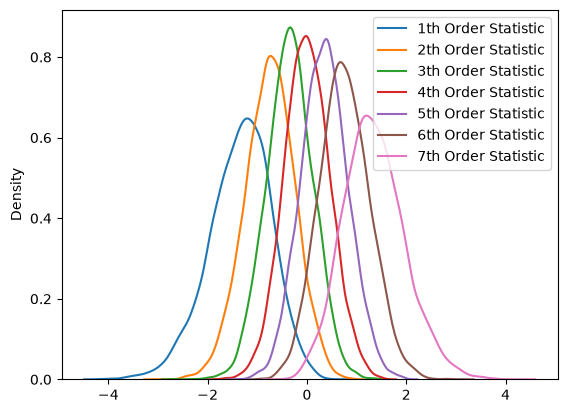

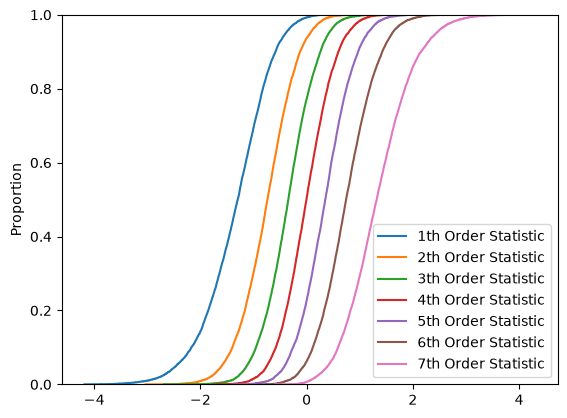

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

rng = np.random.default_rng( seed = 100 ) # Create a random number stream

n = 7 # Sample Size
b = 10_000 # Number of Simulations

sample = rng.standard_normal( size = (n,b) ) # Draw a sample from the standard normal distribution
sorted_sample = np.sort(sample, axis=0) # Sort each column (each simulated sample of size n)

for j in range(n): # For each rank
    sns.kdeplot( sorted_sample[j,:], label=f'{1+j}th Order Statistic') # Plot the KDE
plt.legend() # Add legend
plt.show()

for j in range(n): # For each rank
    sns.ecdfplot( sorted_sample[j,:], label=f'{1+j}th Order Statistic') # Plot the ECDF
plt.legend() # Add legend
plt.show()

## Analytic Relationship

### Maximum
If $F(x)$ is the underlying true CDF, let's consider the analytical equation for the distribution of the maximum of a sample of size $n$. (The maximum is its own random variable, with its distribution plotted above. What is this in math?) To build the CDF of the maximum, we ask (as always): "What's the probability the maximum lands at or below x?" for every x. In other words:
$$F_{max}(x) = P(X_{max} \leq x)$$

This is nothing new, just applying it to the distribution of a specific order statistic, the max.

So what is the **probability that all of the draws are less than or equal to $x$**, i.e. what is the probability that the maximum is less than or equal to $x$ (the right hand side)? Because each draw is independent:

$$P(X_1 \leq x \land ... \land X_n \leq x) = P( X_1 \leq x) \cdot P( X_2 \leq x ) \cdot ... \cdot  P( X_n \leq x)$$

Because we are pulling from the same distribution every time, **each of these probabilities equals our CDF, $F(x)$**:

$$P(X_1 \leq x, ..., X_n \leq x) = F(x) \cdot F(x) ... \cdot F(x)$$

The probability that all of the draws are less than or equal to x is therefore:

$$ F_{\max}(x) = F(x) \cdot F(x) \cdots F(x) = F(x)^n $$

What is its density?

## Minimum
The distribution of the minimum is somewhat harder, because our CDF is asking $\leq x$, and "max $\leq x$" means "all $\leq x$" but "min $\leq x$" does not mean "all $\leq x$". We can't just substitute in multiple copies of $F(x)$.  Instead of looking at the probability that all draws are less than or equal to $x$, we need to know the probability that at least one is.

We want to ask "is the minimum less than or equal to x?" which is the opposite of asking "are all of the draws, including the minimum, above x?" The probability that all observations are above $x$ is $(1-F(x))^{n}$. Because this is the opposite of the question we actually want to ask, the complementary probability is what we truly want:

$$ F_{min}(x) = 1 - (1-F(x))^n $$

What is its density?

## All of the other order statistics, generally
- If you're curious, the density of the $k$-th of $n$ order statistics is

$$
f_k(x) = \dfrac{n!}{(k-1)!(n-k)!} F(x)^{k-1} (1-F(x))^{n-k}f(x)
$$

- We'll use the results for the minimum and maximum

## The Data

We have three datasets:

1. Rainfall *totals* for every state-month from 1981 to 2025, with 5 reporting stations per state each month
2. Rainfall for every *station-day* over that same 1981-2025 period (same 5 stations per state) — much bigger, and used for a single question near the end of Step One
3. Daily and monthly U.S. stock market returns from 1926 to 2026

We want to understand tail behavior, to better reason about risk (engineering, financial, etc.).


In [2]:
df = pd.read_parquet("data/ghcn_prcp_monthly.parquet")
df.head()

,state,state_name,station_rank,station_id,station_name,latitude,longitude,elevation_m,year,month,month_start,prcp_total_mm,observed_total_mm,observed_days,days_in_month,coverage_fraction,prorated,imputed
0,AK,Alaska,1,USW00027502,BARROW AP,71.2869,-156.7394,8.2,1981,1,1981-01-01,5.900001,5.900001,31,31,1.0,False,False
1,AK,Alaska,1,USW00027502,BARROW AP,71.2869,-156.7394,8.2,1981,2,1981-02-01,1.600000,1.600000,28,28,1.0,False,False
2,AK,Alaska,1,USW00027502,BARROW AP,71.2869,-156.7394,8.2,1981,3,1981-03-01,0.900000,0.900000,31,31,1.0,False,False
3,AK,Alaska,1,USW00027502,BARROW AP,71.2869,-156.7394,8.2,1981,4,1981-04-01,5.100000,5.100000,30,30,1.0,False,False
4,AK,Alaska,1,USW00027502,BARROW AP,71.2869,-156.7394,8.2,1981,5,1981-05-01,1.700000,1.700000,31,31,1.0,False,False


**Step One.** 
1. Plot the ECDF and KDE of `prcp_total_mm` with seaborn— the distribution and density of rainfall across the entire U.S.

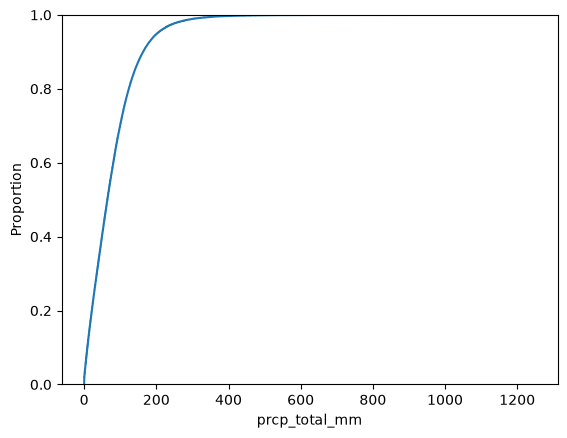

In [3]:
sns.ecdfplot(df["prcp_total_mm"]) 
plt.show()

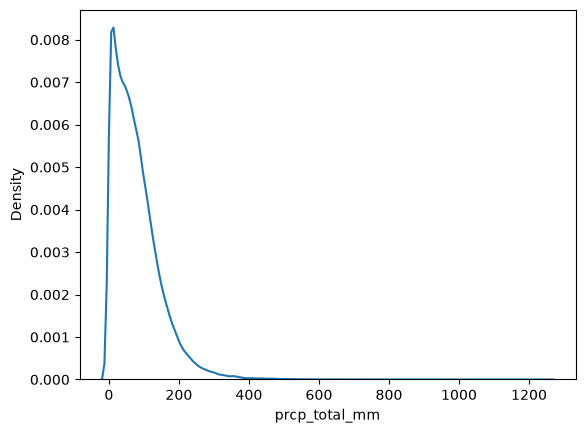

In [4]:
sns.kdeplot(df["prcp_total_mm"]) 
plt.show()

2. Now group by year-month and compute the **median** and **maximum** precipitation nationwide. Plot the ECDF and KDE of these two statistics.

In [5]:
df_median = df.groupby(["year", "month"])["prcp_total_mm"].median()

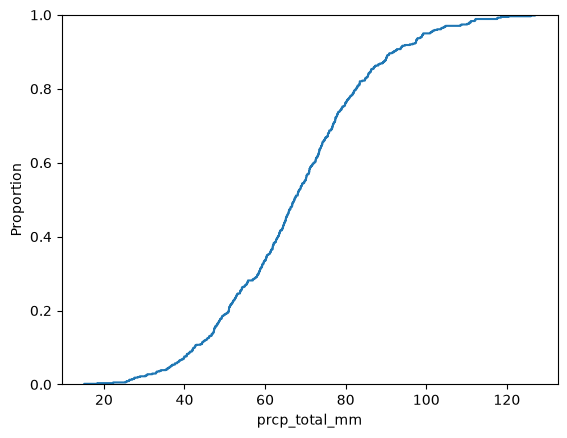

In [6]:
sns.ecdfplot(df_median) 
plt.show()

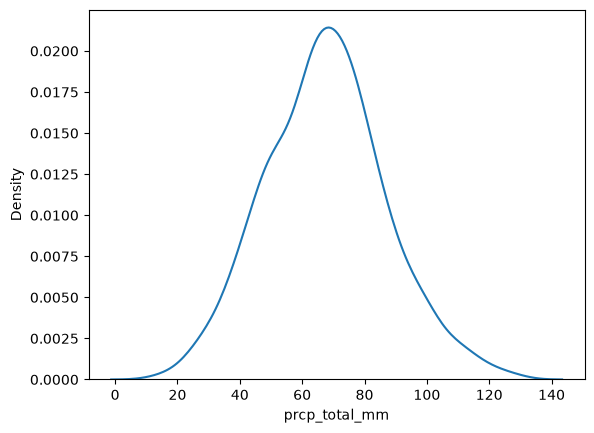

In [7]:
sns.kdeplot(df_median) 
plt.show()

In [8]:
df_max = df.groupby(["year", "month"])["prcp_total_mm"].max()

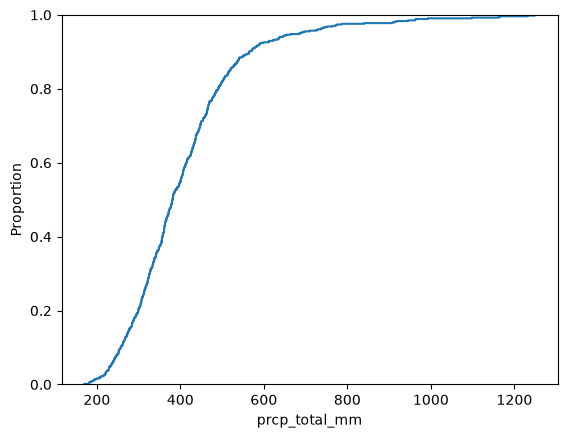

In [9]:
sns.ecdfplot(df_max) 
plt.show()

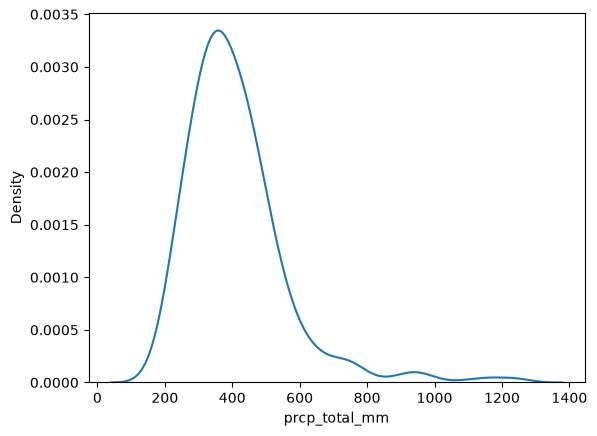

In [10]:
sns.kdeplot(df_max) 
plt.show()

3. How do your results in part 2 compare to your results in part 1?

<div class="alert alert-info">Compare and contrast the ECDFs and KDEs from parts 1 and 2. Explain why they are different:</div>

Side Note: I understand what this exercise is trying to get us to do, but I think it is not modeling what it thinks it is modeling. The point of this demonstration is to illustrate the mathematics from above; namely, how order statistic distributions relate to their original distributions. To do this properly, we really should be taking equal-sized random samples of our original data set and computing the median/maximums from these values, not grouping based on year and month. This grouping is essentially selecting a non-random sample from our data (the variables themselves are certainly not independent), which means the mathematics from above do not apply. 

As compared to original ECDF and KDE, the median ECDF and KDE differs in several ways. First, the ECDF converges to 1 more quickly (roughly by 120 mm) as compared to the original ECDF, which begins to converge at closer to 200 mm. The shapes of the ECDF are similar, but the median ECDF appears more symmetric about an inflection point of 70 mm than the original ECDF, and it has the characteristic convergence "tails" of a normal CDF; in the original ECDF, the interval from 0 to 100 mm roughly appears linear, and only one portion of the graph has a "smooth" convergence tail (the portion converging to 1). Also, the original ECDF is much smoother than the resulting ECDF, but this is moreso a product of the fact that taking medians in the fashion we did reduces the number of points in our sample; we are collapsing many values into one. When we consider the density estimates, the differences become more stark. The original KDE is centered slightly below 100, and it has a skewed right tail that stetches out to well over 200 mm. Alternatively, the KDE of the median is centered at about 70 mm and looks roughly bell-shaped. 

With a broader stroke, we can say that the median computation appeared to make the original KDE and ECDF closer to a normal distribution. Conceptually, when we take a median, we are taking a form of average. In the original distribution, points preserved their indiviual identities and their individual extremeness; it happened that we have more positive extremes than negative (this make sense--you cannot have negative rainfall, so there is an artificial floor). In this grouping median scheme, though, we lose individual granularity, and these extreme values (particularly high values) are dampened by their group membership. Indeed, for an extreme value to persist in this median scheme, most of its group would need to be a relatively similar extreme. Although likely associated (due to temporal connection), this is often more statistically improbable, especially given that this extreme value can be driven by noise (pop-up showers) instead of an underlying phenomenom (massive hurricane/storm). As mentioned above, this interpretation does not fully align with the mathematics because our samples are clearly not random, independent, or constant size.

As compared the original ECDF and KDE, there are significant differences with the maximum ECDF and KDE. ECDF wise, we see a much similar shape (again, slighlty more jagged due to the reduction in points), though the zero "tail" is much smoother now; I do not think the latter fact is very important. If we blur our eyes, we see that this ECDF looks roughly the same shape, but it is translated almost 300 mm to the right. The KDEs convey a similar point. Moreover, the KDE of the maximum is slightly more normal, but I would still consider it skewed right with a peak at about 400 mm. The original KDE is also skewed right, but its center is closer to 100 mm. 

Again, with a broader stroke, we can say that the maximum appeared to shift our original KDE and ECDF to the right by about 300 mm while mostly preserving its skewed right shape. Conceptually, the first part makes sense. If we assume for a moment that points are randomly chosen, then each sample collapses all of its points to its right most point; thus, the density should correspondingly shift rightward. Besides this shift, it is significantly harder to explain the remaining changes, mainly because our assumption of independent and constant sized samples are violated; thus, the distribution cannot be theoretically derived. For this reason, changes in the precise shape, spread, and skewness of the empirical distribution of maxima are consequences of the underlying data and the way they happened to group by month. Simply put, this grouping procedure on any underlying data should consistently produce a rightward shift, but the remaining changes are contigent on the nature of the data and its grouping. 

4. Now define a state's rainfall differently: take the **median** of the 5 stations in each month, then find the **maximum** across the state's 12 months in a year — the "wettest month." For each state, what's the expected value of the wettest month? Plot the ECDF of Virginia's annual maxima (the wettest month in each of the 45 years), and overlay the analytical prediction $F_{\max}(x) = \hat F(x)^{12}$.

Again, it is inappropriate to call this an analytical prediction for the same reasons as above; we are not taking a random sample of 12 elements from our sample, so this is a vast oversimplification.

/var/folders/wn/4vhmdq557_7f8325xdqxk2tr0000gn/T/ipykernel_5384/2166053498.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  state_year_max = state_month.groupby(["state", "year"]).apply(


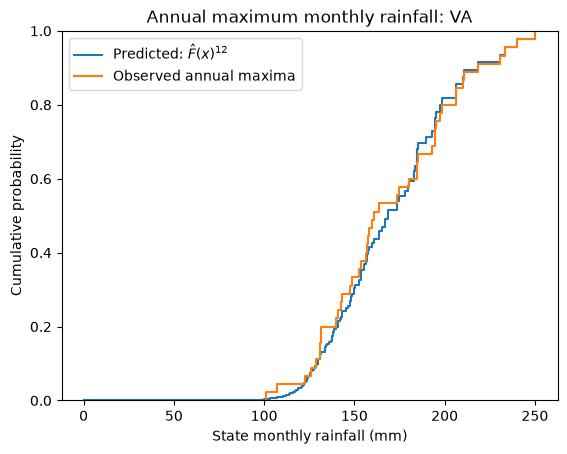

In [11]:
# One rainfall value per state-month, taking the median of the stations
state_month =  df.groupby(["state", "year", "month"])["prcp_total_mm"].median().reset_index()

# Maximum of the 12 state-month observations above, for each year: the wettest month of that year
state_year_max = state_month.groupby(["state", "year"]).apply(
    lambda x: x.loc[x["prcp_total_mm"].idxmax()][["prcp_total_mm"]]
).reset_index()

exp_wettest = state_year_max.groupby("state", as_index=False).agg(E_wettest_month=("prcp_total_mm", "mean"))
exp_wettest.loc[exp_wettest["state"] == "VA"]

state = "VA"

levels = (
    state_month.loc[state_month["state"] == state, "prcp_total_mm"]
    .to_numpy()
)

observed_max = (
    state_year_max.loc[state_year_max["state"] == state, "prcp_total_mm"]
    .to_numpy()
)

x = np.sort(np.unique(levels))
F_hat = np.searchsorted(np.sort(levels), x, side="right") / len(levels)

plt.step(
    x,
    F_hat**12,
    where="post",
    label=r"Predicted: $\hat F(x)^{12}$"
)

sns.ecdfplot(x=observed_max,
    label="Observed annual maxima")

plt.xlabel("State monthly rainfall (mm)")
plt.ylabel("Cumulative probability")
plt.title(f"Annual maximum monthly rainfall: {state}")
plt.legend()
plt.show()

<div class="alert alert-info">How close is the fit here? If it differs from question 4's fit, why:</div>

Roughly speaking, the fit is close, but there are several systematic differences. For rainfalls of 100 mm to roughly 200 mm, the predicted distribution stochastically dominates. For rainfalls above this range, the observed annual maxima appears to momentarily dominate before converging again (it isn't exact). Roughly speaking, this means that the predicted distribution has relatively higher density in the intermediate range (150mm to 200mm), relatively lower density in the lower region, and relatively similar density in the higher region; they still have similar means, though. Should we expect this? It is hard to say. Our predicted distribution assumes complete independence between our 12 observations from the underlying month-year median (fixed state) distribution. In reality, our 12 observations are not independent as they all come from the same year. Are they positively related or negatively related? This is more complicated. Since our empirical distribution has more mass spread to the tails (especially the lower end) while roughly preserving the predicted mean, this suggests a possible positive relationship between precipitation in months in a year. Why? Conceptually, if all the rainfalls tend to move together, then when one is low, they all tend to be low, allowing us to achieve lower maximums consistently. In the independence case, we would need all months to independently produce lower values to achieve low maximums, which is less likely. 

5. **A question for FEMA.** So far you've worked with *monthly* rainfall totals. Switch now to the daily station-level file (`ghcn_prcp_daily.parquet`) — reload `df` from it, and don't mix it with the monthly data above.

   A day with more than 120mm of rain is a serious flood/landslide risk. On any single station-day, that's rare. But a state doesn't get one chance a month — it gets 5 stations $\times$ (days in the month) chances. FEMA doesn't care about the average day, or the single worst day on record; it cares about the probability that *some* station has a disaster day at some point during the month.

   For each state-month, estimate
   $$P(\text{at least one station-day exceeds 120mm}) = 1 - \hat F(120)^n$$
   where $\hat F$ is the empirical CDF of a single station-day's rainfall for that state and calendar month (pooled across all years), and $n$ is the number of station-days in one occurrence of that month (5 stations $\times$ days in the month). Report the 20 highest-risk state-months.


,state,month,p_any_station_day_exceeds_120mm
122,HI,3,0.387166
104,FL,9,0.373367
130,HI,11,0.359242
208,LA,5,0.359229
131,HI,12,0.344789
121,HI,2,0.330060
105,FL,10,0.330026
476,SC,9,0.299512
207,LA,4,0.299512
319,NC,8,0.283726


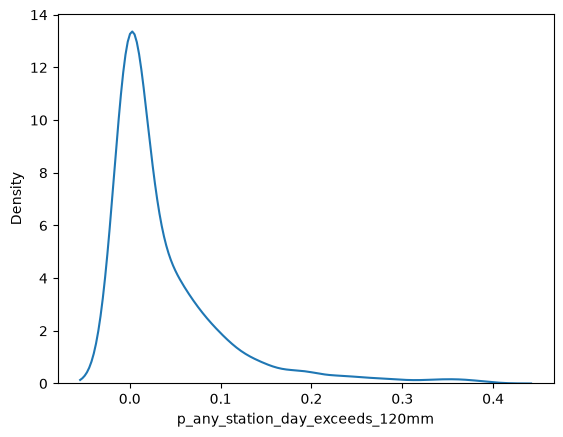

In [12]:
# Fresh load -- this question uses only the daily file, not the monthly one above.
#df_daily = pd.read_parquet("data/ghcn_prcp_daily.parquet")

url = (
    "https://www.dropbox.com/scl/fi/"
    "pjmyop3fqjdy8oabkc4ab/ghcn_prcp_daily.parquet"
    "?rlkey=otxenczb3pxgzz53kc1i5zxww&dl=1"
)
df_daily = pd.read_parquet(url)
df_daily = df_daily.loc[df_daily["observed"]]

threshold = 120  # mm in a single day

def disaster_risk(group):
    F_hat = (group["prcp_mm"] <= threshold).mean()
    n = len(group) / group["year"].nunique()  # station-days in one year's occurrence of this month
    return 1 - F_hat**n

risk = (
    df_daily.groupby(["state", "month"])
            .apply(disaster_risk, include_groups=False)
            .rename("p_any_station_day_exceeds_120mm")
            .reset_index()
            .sort_values("p_any_station_day_exceeds_120mm", ascending=False)
)

sns.kdeplot(risk['p_any_station_day_exceeds_120mm'])

risk.head(20)

<div class="alert alert-info">Which states and months face the most risk of a greater-than-120mm day? How high is the probability? Among all state-months, describe the density of high precipitation days:<div>

In terms of months, May to October is overrepresented in the top state-month probabilities, making up about 60% of the table. In terms of states, southern states dominate (Florida, Lousiana, Georgia, South Carolina, North Carolina, Virginia?), as well as Hawaii. As for state-month combinations, the greatest estimated risk occurs in Hawaii in March ($.387%$ probability), followed by Florida in September ($.373$ probability), Hawaii in November ($0.359$ probability), and Lousiana in May ($0.359$ probability). Among all state-months, the density of the high precipitation days has most of its mass in the range of $0$ to $0.1$, and it is skewed right with a positive tail; there is appreciable density up until roughly $0.3$.

**Step Two.**

Our second data set is daily and monthly U.S. stock market returns. Instead of storms across space (five stations in a state) or across the calendar (twelve months in a year), the "sample" is the set of trading days within a month, and we ask about the best and worst day in that sample.

In [13]:
df = pd.read_parquet("data/ff_market_daily.parquet")

print(f"{len(df):,} trading days")
print(f"{df['date'].min().date()} through {df['date'].max().date()}")
df.head()

26,296 trading days
1926-07-01 through 2026-07-31


,date,year,month,month_start,trading_day_of_month,mkt_excess_return_pct,risk_free_return_pct,market_return_pct,absolute_market_return_pct
0,1926-07-01,1926,7,1926-07-01,1,0.09,0.01,0.10,0.10
1,1926-07-02,1926,7,1926-07-01,2,0.45,0.01,0.46,0.46
2,1926-07-06,1926,7,1926-07-01,3,0.17,0.01,0.18,0.18
3,1926-07-07,1926,7,1926-07-01,4,0.09,0.01,0.10,0.10
4,1926-07-08,1926,7,1926-07-01,5,0.22,0.01,0.23,0.23


1. Plot the KDE and ECDF of daily market returns.

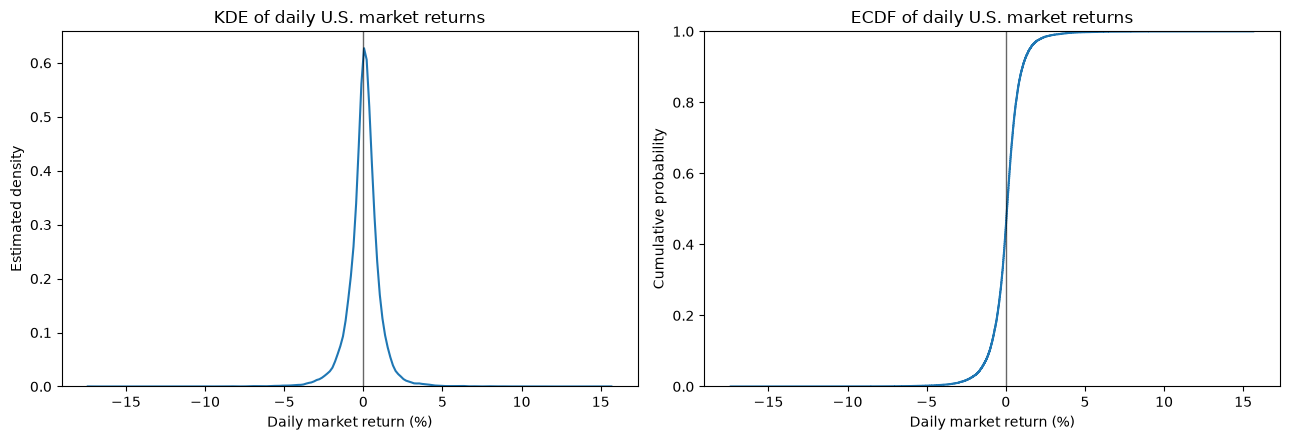

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.kdeplot(
    data=df,
    x="market_return_pct",
    cut=0,
    ax=axes[0],
)
axes[0].axvline(0, color="black", linewidth=1, alpha=0.6)
axes[0].set(
    title="KDE of daily U.S. market returns",
    xlabel="Daily market return (%)",
    ylabel="Estimated density",
)

sns.ecdfplot(
    data=df,
    x="market_return_pct",
    ax=axes[1],
)
axes[1].axvline(0, color="black", linewidth=1, alpha=0.6)
axes[1].set(
    title="ECDF of daily U.S. market returns",
    xlabel="Daily market return (%)",
    ylabel="Cumulative probability",
)

plt.tight_layout()
plt.show()

2. For each calendar month, compute the **best** (max) and **worst** (min) daily return — the first and $n$-th order statistics of that month's trading days. Plot the KDE of the monthly best and worst returns, overlaid.

In [15]:
monthly = (
    df.groupby(["year", "month"], as_index=False)
         .agg(
             month_start=("month_start", "first"),
             trading_days=("date", "size"),
             worst_return_pct=("market_return_pct", "min"),
             best_return_pct=("market_return_pct", "max"),
             median_return_pct=("market_return_pct", "median"),
         )
)

# Put losses and gains on the same positive-magnitude scale.
monthly["worst_loss_pct"] = -monthly["worst_return_pct"]

print(f"{len(monthly):,} calendar months")
print(
    f"Trading days per month: {monthly['trading_days'].min()} "
    f"to {monthly['trading_days'].max()}"
)
monthly.head()

1,201 calendar months
Trading days per month: 15 to 27


,year,month,month_start,trading_days,worst_return_pct,best_return_pct,median_return_pct,worst_loss_pct
0,1926,7,1926-07-01,25,-0.72,1.10,0.18,0.72
1,1926,8,1926-08-01,26,-1.39,0.85,0.32,1.39
2,1926,9,1926-09-01,24,-0.98,0.91,-0.03,0.98
3,1926,10,1926-10-01,25,-1.81,1.53,-0.09,1.81
4,1926,11,1926-11-01,24,-0.62,0.67,0.19,0.62


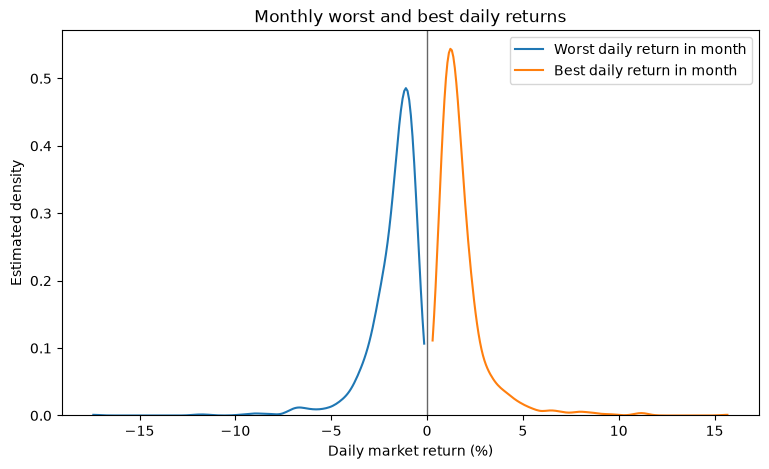

In [16]:
plt.figure(figsize=(9, 5))
sns.kdeplot(
    x=monthly["worst_return_pct"],
    label="Worst daily return in month",
    cut=0,
)
sns.kdeplot(
    x=monthly["best_return_pct"],
    label="Best daily return in month",
    cut=0,
)
plt.axvline(0, color="black", linewidth=1, alpha=0.6)
plt.xlabel("Daily market return (%)")
plt.ylabel("Estimated density")
plt.title("Monthly worst and best daily returns")
plt.legend()
plt.show()

In [17]:
from scipy.stats import gaussian_kde

def kde_mode(data):
    kde = gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 10000)
    density = kde(x)
    return x[np.argmax(density)]

worst_mode = kde_mode(monthly["worst_return_pct"])
best_mode = kde_mode(monthly["best_return_pct"])

print("Worst-day KDE mode:", worst_mode)
print("Best-day KDE mode:", best_mode)

Worst-day KDE mode: -1.1028472847284725
Best-day KDE mode: 1.2344264426442644


In [18]:
print("1% tails:",
      abs(monthly["worst_return_pct"].quantile(0.01)),
      monthly["best_return_pct"].quantile(0.99))

print("5% tails:",
      abs(monthly["worst_return_pct"].quantile(0.05)),
      monthly["best_return_pct"].quantile(0.95))

print("10% tails:",
      abs(monthly["worst_return_pct"].quantile(0.1)),
      monthly["best_return_pct"].quantile(0.9))

1% tails: 6.970000000000001 7.93
5% tails: 4.06 4.21
10% tails: 3.18 3.12


<div class="alert alert-info">Describe the symmetry (or lack of it) between the best- and worst-day densities. Compare them to the overall populations of daily returns. Use code as appropriate to make these comparisons, and then write out your answer in a markdown cell.</div>

Roughly speaking, the best and worst-day densities mirror each other, but not perfectly. The worst-day has a mode of about $-1.1\%$ compared to the best-day mode of $1.23\%$, so the mode of the best-day densities is slightly further away from $0$. Moreover, the peak of the density for the best-day is higher and narrower than the worst-day, suggesting that the worst-day's intermediate values are more dispersed around its mode. Visually, both distributions are skewed (skewed left for worst-day, skewed right for best-day), but the tail of best-day is slightly longer; this is confirmed by the tail quantiles displayed above, where the $10\%$ and $5\%$ tails are relatively identical, but the $1\%$ tail of the best-day is almost $1\%$ larger than the worst-day (this means the $1\%$ most extreme values of the best-day meaningfully exceed the $1\%$ most extreme values of the worst-day). Interestingly, the worst-day has a tiny cluster right around $-7\%$ (about within the most extreme tail), which is not seen in the best-day; it is almost as if all of the extreme values for worst-day ($-5\%$ and above) cluster around $-6.5\% \to -7\%$, whereas equally extreme values for best-day are more uniformly distributed over the range. 

3. Losses and gains are on opposite sides of zero, which makes them hard to compare directly. Put them on the same scale by looking at the *magnitude* of the worst loss (`-worst_return_pct`) against the magnitude of the best gain (`best_return_pct`). Plot both the KDE and ECDF.

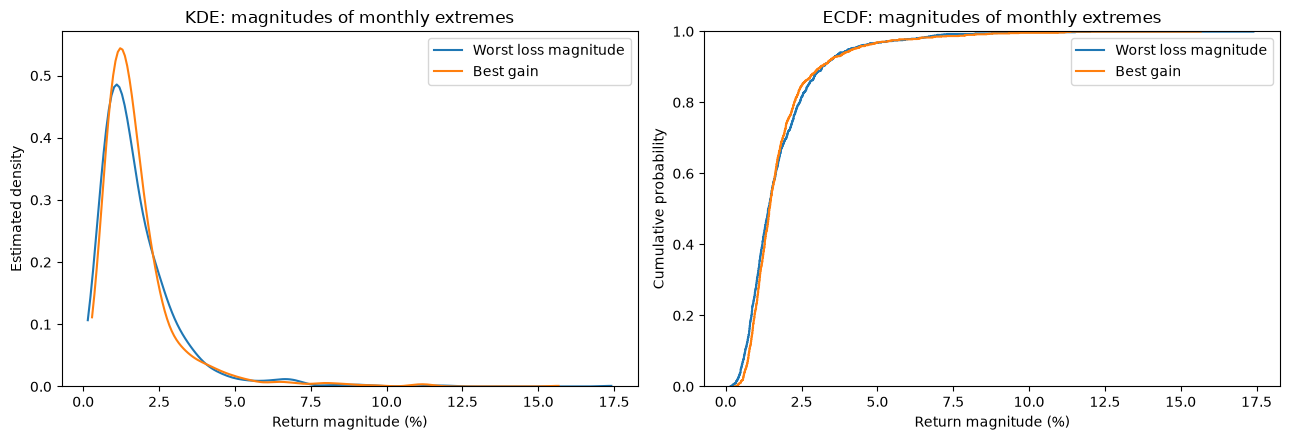

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.kdeplot(
    x=monthly["worst_loss_pct"],
    label="Worst loss magnitude",
    cut=0,
    ax=axes[0],
)
sns.kdeplot(
    x=monthly["best_return_pct"],
    label="Best gain",
    cut=0,
    ax=axes[0],
)
axes[0].set(
    title="KDE: magnitudes of monthly extremes",
    xlabel="Return magnitude (%)",
    ylabel="Estimated density",
)
axes[0].legend()

sns.ecdfplot(
    x=monthly["worst_loss_pct"],
    label="Worst loss magnitude",
    ax=axes[1],
)
sns.ecdfplot(
    x=monthly["best_return_pct"],
    label="Best gain",
    ax=axes[1],
)
axes[1].set(
    title="ECDF: magnitudes of monthly extremes",
    xlabel="Return magnitude (%)",
    ylabel="Cumulative probability",
)
axes[1].legend()

plt.tight_layout()
plt.show()

<div class="alert alert-info">Are large losses more extreme than large gains, or about the same:</div>

This question asks us to primarily focus on the tails of these two distributions, which roughly begin at a magnitude of $3\%$ (this roughly corresponds to the $10\%$ tail). Visually, this region is strange. From about $3\%$ to $4\%$ magnitude, the worst loss density exceeds the best gain density. Then, from about $4\%$ to $5\%$ magnitude, the best gain density exceeds the worst loss density. In the region from $5\%$ to $7\%$, the density flips again (worst density > best density). Finally, beyond $7\%$, the best gain density marginally exceeds the worst density. This pattern goes back to the discussion from the previous question. More specifically, the best gains appear to have negligibly more total density in the region beyond $3\%$; this is not obvious from the visual and is mostly coming from the tail analysis above, where the $10\%$ tail of the best day is slightly greater than the $10\%$ tail of the worst day. However, the worst losses have a highly concentrated group of values around $6\%$ to $7\%$, which looks especially pronounced in the visual, whereas the extreme values of best days are more well dispersed. This dispersion results in no noticeable bumps but a consistently larger value for magntiudes that exceed $7\%$. Overall, I would say that the large gains are slightly more extreme than large losses, but the difference is probably not meaningful for practical purposes. 

4. Compute the median, 75th, 90th, 95th, and 99th percentile of both magnitudes from question 3. In what fraction of months does the worst loss exceed the best gain in magnitude?

In [20]:
tail_summary = pd.DataFrame(
    {
        "Worst loss magnitude": monthly["worst_loss_pct"],
        "Best gain": monthly["best_return_pct"],
    }
).quantile([0.50, 0.75, 0.90, 0.95, 0.99]).T

tail_summary.columns = ["median", "75%", "90%", "95%", "99%"]

print(
    "Fraction of months in which the worst loss exceeded the best gain: "
    f"{(monthly['worst_loss_pct'] > monthly['best_return_pct']).mean():.1%}"
)
tail_summary.round(2)

Fraction of months in which the worst loss exceeded the best gain: 44.8%


,median,75%,90%,95%,99%
Worst loss magnitude,1.41,2.21,3.18,4.06,6.97
Best gain,1.44,2.04,3.12,4.21,7.93


<div class="alert alert-info">What does this tail comparison say about the risk of losses vs. gains:</div>

I am mostly going to copy what I discussed in the previous response. The median magnitudes are, for all intents and purposes, the same; this means that the total density beyond a magnitude of $1.4\%$ is roughly the same for both distributions. However, the width between the $50\%$ and $75\%$ percentile for worst loss is about $0.2\%$ larger than the best gain; this suggests that the third quartile of worst loss is more spread out than the third quartile of best gain. Alternatively, the width between the $90\%$ and $95\%$ quantiles of best gain is roughly $0.2\%$ larger than the worst loss, suggesting more dispersion in this quantile region for the former. Finally, the $99\%$ quantile of best day is about $1\%$ larger than the worst day. This not only indicates that the quantile region of $95\%$ to $99\%$ is more dispersed for the best day, but it also shows that the $1\%$ most extreme gains sit comfortably above the $1\%$ most extreme losses. The latter fact is probably the cleanest and most telling insight of these quantile comparisons. That is, the two distributions are similar for most of their ranges, but at the most extreme quantiles, the best day gains appear larger in magnitude. 

5. Plot the monthly best and worst daily returns over time. Do the extremes look stable across this ~100-year history, or are there periods where they're much larger? Can you identify any famous market events?

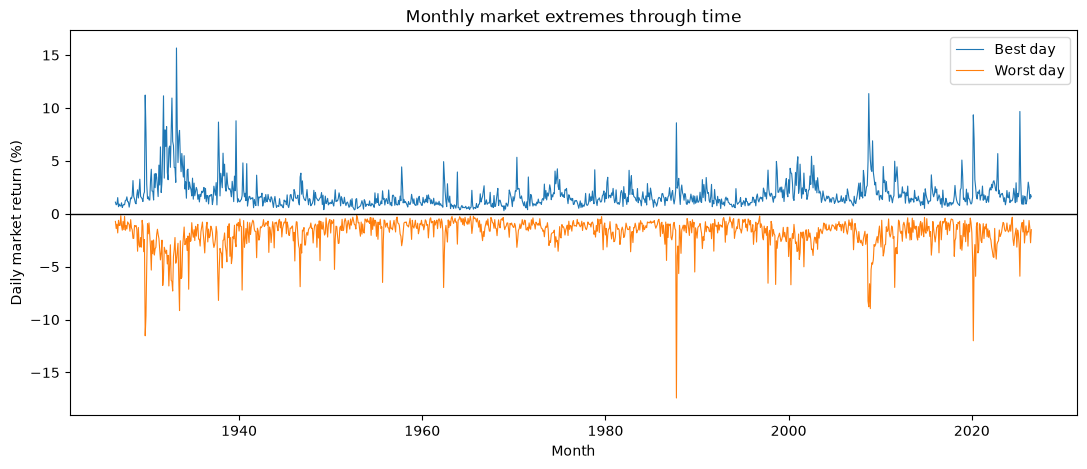

In [21]:
plt.figure(figsize=(13, 5))
plt.plot(
    monthly["month_start"],
    monthly["best_return_pct"],
    linewidth=0.8,
    label="Best day",
)
plt.plot(
    monthly["month_start"],
    monthly["worst_return_pct"],
    linewidth=0.8,
    label="Worst day",
)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Month")
plt.ylabel("Daily market return (%)")
plt.title("Monthly market extremes through time")
plt.legend()
plt.show()

<div class="alert alert-info">Do upside and downside risk tend to go together (volatility), or does the market exhibit distinct periods in which the good shocks are concentrated and the bad shocks are concentrated? What implication does this have for investing?:</div> 

In general, upside and downside risk tend to go together; this is reflected by the horizontal symmetry of the extremes; reflecting our best day graph about the zero return line roughly produces the worst day graph. In other words, when best days achieve largest percentage market returns, worst days often achieve the greatest market losses. Several distinct events are apparent, including the Great Depression (1930s), Black Monday (1987), the Great Recession (2008), and COVID-19 (2020). Note that the volatility comparison is not exact; in some cases, such as Black Monday, the worst losses are slightly larger than the best gains, but they are roughly of the same order. As far as investing is concerned, Sun Tzu summarizes it best: "In the midst of chaos, there is also opportunity". Indeed, in times of great change/volatility, which may be spurred by good or bad events, there exist the greatest chances for both big gain and losses. 

## Wrap-up



<div class="alert alert-info">This week has focused on kernel density estimation, particularly estimating the PDF from data. This lab takes that a step further: We can estimate and quantify the densities and distributions of random variables that build off of observed phenomena. What is the difference between the ECDF and KDE? Explain how these estimations today give us different information than an ECDF or KDE plot of the underlying data, but quantify information about the behavior of a different random variable.</div>

The Kernel Density Estimate (KDE) for a random variable can be understood as the estimator for the random variable's true/population density function--a function whose area under a given region indicates the probability of the random variable taking on values within that region. Alternatively, the Empirical Cumulative Distribution Function (ECDF) can be understood as the estimator of the true/population cumulative distribution function--a function that takes in a real-value input and indicates the probability of the random variable taking on a value at most the input. In this lab, we worked to construct KDEs and ECDFs, but we did not construct these functions for the original random variable. Instead, we constructed a new random variable, which took the general form of an operation (mean, maximum, median, etc.) applied to a finite number of random variables (our original variable(s)). In most cases, this collection of random variables were neither independent nor identically distributed, yet making such assumptions and computing theortical distributions resulted in comparable results to the empirical distributions.